###### Load Dependencies

In [2]:
from importlib import reload
from data import *
from classifications import *
import data as db
import matplotlib.pyplot as plt
reload( db )
import pandas as pd
import warnings

In [4]:
reload( db )
hdr = '\r\n' + '-' * 120 + '\r\n'
nwln = '\r\n'
warnings.filterwarnings( 'ignore' )

###### Load Data

In [5]:
# Load Data
schedx_filepath = r'C:\Users\terry\source\repos\mathy\stores\excel\Combined Schedules.xlsx'
nominal_columns = [ 'CombinedSchedulesId', 'MainAccount', 'TreasurySymbol', 'AccountName',
					'LineName', 'Line', 'Subfunction', 'Classification', 'BudgetEnforcementCategory' ]
out_years = [ f'OY-{i}' for i in range( 1, 10 ) ]
numeric_columns = [ 'PY', 'CY', 'BY' ]
data_columns = [ 'MainAccount', 'LineName', 'Line' ]
all_columns = nominal_columns + numeric_columns
index_columns = [ 'CombinedSchedulesId', ]
drop_columns = [ 'CombinedSchedulesId', 'LineName', 'Subfunction', 'Classification',
				 'BudgetEnforcementCategory' ]
max_columns = data_columns + numeric_columns

# Read Excel, set index and load columns# Reload with corrected dtypes and padding for codes
dtype_dict = \
{
	'MainAccount': str,
	'TreasurySymbol': str
}

df_excel = pd.read_excel( schedx_filepath, usecols=all_columns, sheet_name='Data'  )
df_excel.reset_index( )
df_excel.round( 2 )
# Fix formatting: pad with leading zeros and split TreasurySymbol
df_excel[ 'MainAccount' ] = df_excel[ 'MainAccount' ].str.replace( 'A-', '', regex=False )
df_excel[ 'MainAccount' ] = df_excel[ 'MainAccount' ].str.zfill( 4 )
df_excel[ 'TreasurySymbol' ] = df_excel[ 'TreasurySymbol' ].str.replace( 'A-', '', regex=False )
df_excel[ 'Line' ] = df_excel[ 'Line' ].str.replace( 'L-', '', regex=False )
df_excel[ 'Line' ] = df_excel[ 'Line' ].str.zfill( 4 )
df_excel[ 'AgencyCode' ] = df_excel[ 'TreasurySymbol' ].str[ :3 ].str.zfill( 3 )
df_excel[ 'MainAccountCode' ] = df_excel[ 'TreasurySymbol' ].str[ 3: ].str.zfill( 4 )


df_excel[ numeric_columns ] = df_excel[ numeric_columns ].round( 2 )
df_dataset = df_excel[ all_columns ].copy( )
df_nominal = df_excel[ nominal_columns ].copy( )
df_numeric = df_excel[ numeric_columns ].copy( )
df_schedx = df_excel[ max_columns ].copy( )
sns.set_style( 'darkgrid' )


print( hdr )
print( 'Balances DataSource' )
print( nwln )

# Descriptive Statistics & Probability Distributions
df_descriptive = df_schedx.describe( percentiles=[ .05, .1, .25, .3, .5, .75, .8, .9, .95 ] )
df_descriptive.round( 2 )


------------------------------------------------------------------------------------------------------------------------

Balances DataSource




,PY,CY,BY
count,2.400000e+03,2.400000e+03,2.400000e+03
mean,6.156629e+08,6.235775e+08,6.192235e+09
std,3.507293e+09,3.584782e+09,1.430772e+11
min,-7.069000e+09,-3.342300e+10,-1.257400e+10
5%,-7.000000e+06,-6.000000e+06,-6.000000e+06
10%,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00
30%,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.000000e+06,1.000000e+06,1.000000e+06
75%,5.000000e+07,4.500000e+07,4.425000e+07


In [6]:
ds = db.DataSource( df=df_numeric, target='BY' )
X = ds.data
y = ds.targets

In [7]:
model = LogisticRegression( )
model.train( X, y )

In [8]:
prediction = model.project( X, y )
prediction

array([  50254000000,   50254000000,   50254000000, ...,   50254000000,
         50254000000, 4528039000000], shape=(2400,))

In [10]:
accuracy = model.score( X, y )
accuracy

-59.281686255497405

In [11]:
analysis = model.analyze( X, y )
analysis

{'MSE': np.float64(-1.3186489690212306e+18),
 'RMSE': np.float64(-1.3186489690212306e+18),
 'R2': -59.281686255497405,
 'VAR': -55.13708590234232,
 'MAE': np.float64(3235000000.0)}

In [9]:
decision = model.decision_function( X )
decision

array([[-1.73403151e-01, -7.02078528e-02, -5.85295014e-02, ...,
         7.90588179e-02,  7.89194442e-02,  7.90317827e-02],
       [-1.57814188e-02, -6.38961590e-03, -5.32676927e-03, ...,
         7.19514214e-03,  7.18245774e-03,  7.19268167e-03],
       [-5.58123349e-03, -2.25974221e-03, -1.88385743e-03, ...,
         2.54462344e-03,  2.54013749e-03,  2.54375327e-03],
       ...,
       [-4.15042866e-03, -1.76161240e-03, -1.45840006e-03, ...,
         2.67690160e-03,  2.67401476e-03,  2.67653856e-03],
       [-3.81573303e-03, -1.63962969e-03, -1.35501020e-03, ...,
         2.65507514e-03,  2.65253217e-03,  2.65481163e-03],
       [-1.39618380e+00, -9.41453575e-01, -7.37650862e-01, ...,
         4.27234282e+00,  4.27330166e+00,  4.27344138e+00]],
      shape=(2400, 426))

In [10]:
probability = model.predict_probability( X )
probability


array([[0.00196977, 0.0021839 , 0.00220955, ..., 0.00253547, 0.00253512,
        0.0025354 ],
       [0.00231063, 0.00233243, 0.00233491, ..., 0.00236433, 0.0023643 ,
        0.00236433],
       [0.00233435, 0.00234211, 0.002343  , ..., 0.00235339, 0.00235338,
        0.00235339],
       ...,
       [0.00233769, 0.00234328, 0.00234399, ..., 0.00235371, 0.0023537 ,
        0.00235371],
       [0.00233848, 0.00234357, 0.00234424, ..., 0.00235366, 0.00235365,
        0.00235366],
       [0.0002071 , 0.00032634, 0.00040011, ..., 0.05997735, 0.06003489,
        0.06004328]], shape=(2400, 426))

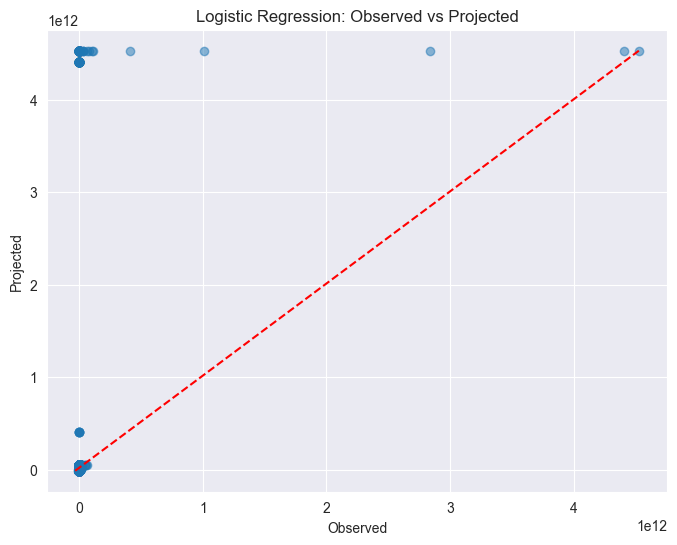

In [9]:
model.scatter_plot( X, y )

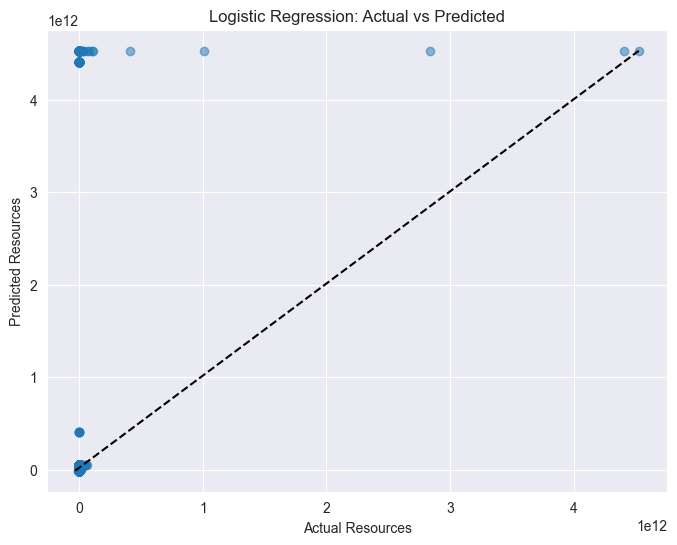

In [10]:
model.visualize( X, y )

KeyboardInterrupt: 

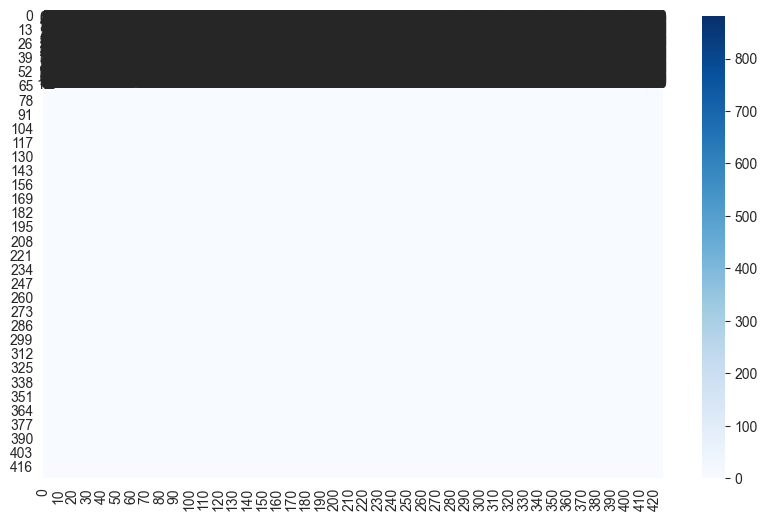

In [9]:
model.create_matrix( X, y )